<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/%22pytorch_bn_dropout_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

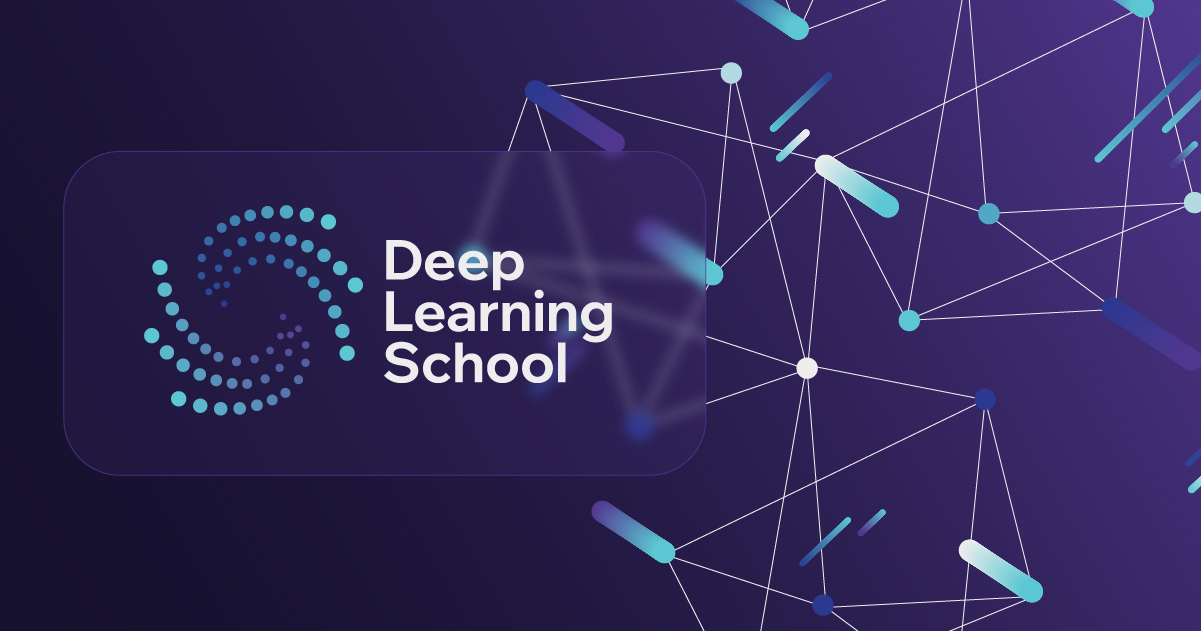

<h3 style="text-align: center;"><b>"Глубокое обучение". Продвинутый поток</b></h3>

<h2 style="text-align: center;"><b>Семинар. PyTorch. Батчнорм и дропаут. </b></h2>


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.notebook import tqdm

sns.set(font_scale=1.4, style="whitegrid")

In [ ]:
# Зафиксируем сиды для воспроизводимости
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# Выберем cuda или cpu
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

# Загрузка датасета

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) — это набор данных, состоящий из 60 000 цветных изображений размером $32 \times 32$ пикселя, разделённых на 10 классов (например, самолёты, автомобили, птицы, кошки и др.). Из них 50 000 изображений используются для обучения моделей, а 10 000 — для их тестирования. Этот датасет широко применяется в задачах компьютерного зрения и отлично подходит для экспериментов с PyTorch.


In [ ]:
classes = ("plane", "car", "bird", "cat",
           "deer", "dog", "frog", "horse", "ship", "truck")

def get_dataloaders(batch_size):

#Compose — это просто "склеиватель" нескольких преобразований в одну цепочку.
#Он принимает список трансформаций и применяет их по очереди, передавая результат каждой следующей:
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) #M = 0.5 std = 0.5

    trainset = datasets.CIFAR10(root="./data", train=True,
                                            download=True, transform=transform)

    #DataLoader позволяет создать батчи, чтобы передавать изображения по батчам, также распараллелить процесс при помощи num_workers.
    trainloader = DataLoader(trainset, batch_size=batch_size,
                                              shuffle=True, num_workers=2)
    testset = datasets.CIFAR10(root="./data", train=False,
                                           download=True, transform=transform)
    testloader = DataLoader(testset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    return trainloader, testloader

В PyTorch датасетом считается любой объект, для которого определены методы `__len__(self)` и `__getitem__(self, i)`.

# Код обучения

In [ ]:
def train_one_epoch(model, loss_func, optimizer, train_dl):
    """
    Train the model for one epoch.

    Args:
        model (torch.nn.Module): Model to be trained.
        loss_func (callable): Loss function.
        optimizer (torch.optim.Optimizer): Optimization algorithm.
        train_dl (DataLoader): Dataloader for the training set.

    Returns:
        float: Average training loss over the entire epoch.
    """
    model.train()  # Set model to training mode
    total_loss = 0.0

    for xb, yb in tqdm(train_dl, desc="Training"):
        # Move data to the appropriate device
        xb, yb = xb.to(device), yb.to(device)

        # Forward pass
        preds = model(xb)
        loss = loss_func(preds, yb)

        # Accumulate loss
        total_loss += loss.item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # Return the average loss
    return total_loss / len(train_dl)


def validate(model, loss_func, valid_dl):
    """
    Validate the model on a given validation set.

    Args:
        model (torch.nn.Module): Model to be validated.
        loss_func (callable): Loss function.
        valid_dl (DataLoader): Dataloader for the validation set.

    Returns:
        float: Average validation loss over the entire validation set.
        float: Accuracy of the model on the validation set (0 to 1).
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # for validation we don't need calculate gradients
    # ! eval() mode doen't turn off gradients !
    with torch.no_grad():
        for xb, yb in tqdm(valid_dl, desc="Validation"):
            # Move data to the appropriate device
            xb, yb = xb.to(device), yb.to(device)

            # Forward pass
            preds = model(xb)
            loss = loss_func(preds, yb)
            total_loss += loss.item()

            # Compute accuracy
            _, predicted_labels = torch.max(preds, dim=-1)
            '''
                      Math  Physics  History  Biology
            Ученик 0:  0.1    0.8      0.05    0.05
            Ученик 1:  0.6    0.1      0.2     0.1
            Ученик 2:  0.1    0.1      0.1     0.7

            torch.max(preds, dim=-1) отвечает на вопрос:

            "По какому предмету у каждого ученика максимальная оценка?"

            Смотрим по каждой строке → и находим максимум:
            Ученик 0:  максимум 0.8  → индекс 1 (Physics)
            Ученик 1:  максимум 0.6  → индекс 0 (Math)
            Ученик 2:  максимум 0.7  → индекс 3 (Biology)



            dim=0 — смотрим вниз по столбцам ↓

            "Кто из учеников лучший по каждому предмету?"

            Math:    максимум 0.6 → Ученик 1
            Physics: максимум 0.8 → Ученик 0
            History: максимум 0.2 → Ученик 1
            Biology: максимум 0.7 → Ученик 2

            predicted = [1, 0, 1, 2]

            dim=1 — смотрим вправо по строкам →

            "По какому предмету каждый ученик лучший?"

            Ученик 0: максимум 0.8 → Physics (индекс 1)
            Ученик 1: максимум 0.6 → Math    (индекс 0)
            Ученик 2: максимум 0.7 → Biology (индекс 3)

            predicted = [1, 0, 3]

            '''



            total_correct += (predicted_labels == yb).sum().item()
            total_samples += xb.size(0)

    avg_loss = total_loss / len(valid_dl)
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


def fit(epochs, model, loss_func, optimizer, train_dl, valid_dl):
    """
    Train and validate a model over a specified number of epochs.

    Args:
        epochs (int): Number of epochs to train.
        model (torch.nn.Module): Model to be trained and validated.
        loss_func (callable): Loss function (e.g., nn.CrossEntropyLoss()).
        optimizer (torch.optim.Optimizer): Optimization algorithm (e.g., SGD).
        train_dl (DataLoader): Dataloader for the training set.
        valid_dl (DataLoader): Dataloader for the validation set.

    Returns:
        tuple:
            - train_losses (list of float): Average training losses per epoch.
            - val_losses (list of float): Average validation losses per epoch.
            - valid_accuracies (list of float): Validation accuracies per epoch.
    """
    train_losses = []
    val_losses = []
    valid_accuracies = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Train for one epoch
        train_loss = train_one_epoch(model, loss_func, optimizer, train_dl)

        # Validate after the epoch
        val_loss, val_acc = validate(model, loss_func, valid_dl)

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        valid_accuracies.append(val_acc)

        # Print a summary for quick reference
        print(f"Epoch {epoch+1} -> "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, valid_accuracies

In [ ]:
def plot_training(train_losses, valid_losses, valid_accuracies):
    """
    Plots training and validation losses, and validation accuracy over epochs.
    """
    plt.figure(figsize=(12, 9))

    # Plot training and validation losses in the first subplot
    plt.subplot(2, 1, 1) #обращаемся к первому подграфику, на нем будут Loss на трейн/val
    plt.xlabel("epoch")
    plt.plot(train_losses, label="train_loss")
    plt.plot(valid_losses, label="valid_loss")
    plt.legend()

    # Plot validation accuracy in the second subplot
    plt.subplot(2, 1, 2) #обращаемся ко второму графику, на нем будет accuracy на val выборке
    plt.xlabel("epoch")
    plt.plot(valid_accuracies, label="valid accuracy")
    plt.legend()

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 5x5 image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Далее мы запускаем обучение модели:
- Определяем функцию потерь ([CrossEntropyLoss](https://colab.research.google.com/drive/1EOlgKwXSj9z7JqBl9sz2Xg-pfv2Xjw7e#scrollTo=RQygJ0ZHCgCK&line=2&uniqifier=1)) и оптимизатор ([SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) с параметрами $\text{lr}=0.001$ и $\text{momentum}=0.9$).
- Запускаем обучение модели на $10$ эпох с помощью функции `fit` и визуализируем результаты (графики потерь и точности) с помощью plot_training.

100%|██████████| 170M/170M [00:04<00:00, 34.1MB/s]



Epoch 1/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 1 -> Train Loss: 1.7274 | Val Loss: 1.3734 | Val Acc: 0.5029

Epoch 2/10


...

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 9 -> Train Loss: 0.7233 | Val Loss: 1.0518 | Val Acc: 0.6588

Epoch 10/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 10 -> Train Loss: 0.6823 | Val Loss: 1.1342 | Val Acc: 0.6499


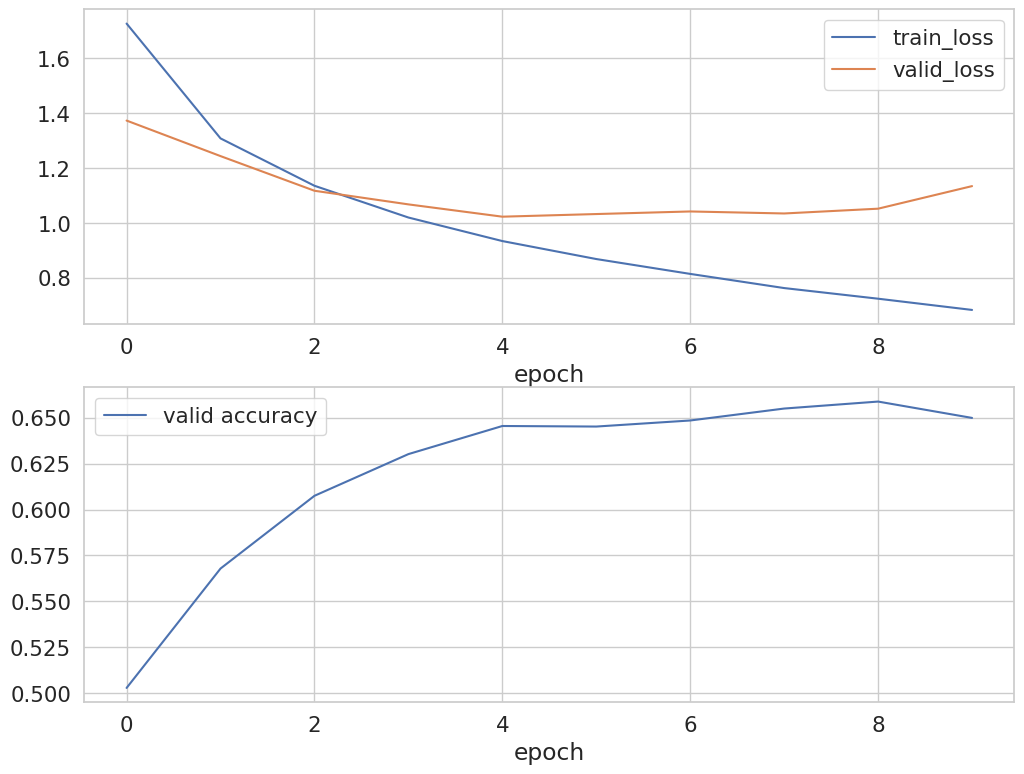

In [ ]:
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

info = fit(10, model, criterion, optimizer, *get_dataloaders(4))
plot_training(*info)

# BatchNorm
Ранее мы обсуждали, что для линейных моделей очень важно нормировать признаки перед подачей на вход. Когда мы работаем с нейронными сетями мы тоже нормируем вход, но есть ли какой-то способ нормировать признаки на внутренних слоях нейроной сети?

Да, существует несколько метдов нормировки признаков (BatchNorm, LayerNorm, InstanceNorm, etc). Научимся применять BatchNorm.


### BatchNorm, математика

<img src="https://production-media.paperswithcode.com/methods/batchnorm.png">

Если коротко, то `BatchNorm` для каждого признака вычитает среднее значение по батчу и делит на стандартное отклонение по батчу, потом домножает все признаки на вес $\gamma$ и прибавляет вес $\beta$. При этом возникает вопрос, что если мы используем модель уже для предсказаний и можем запускать ее только на одном примере.

`BatchNorm` работает по разному во время обучения и предсказний:


**Во время обучения**. Пусть батч состоит из $\mathbf{x_i}$ (каждый $\mathbf{x_i}$ - вектор, подающийся на вход). Тогда
$$\begin{aligned}
\mu_{\mathcal{B}} & \leftarrow \frac{1}{m} \sum_{i=1}^{m} x_{i} \\
\sigma_{\mathcal{B}}^{2} & \leftarrow \frac{1}{m} \sum_{i=1}^{m}\left(x_{i}-\mu_{\mathcal{B}}\right)^{2} \\
\widehat{x}_{i} & \leftarrow \frac{x_{i}-\mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^{2}+\epsilon}} \\
y_{i} & \leftarrow \gamma \widehat{x}_{i}+\beta \equiv \mathrm{B} \mathrm{N}_{\gamma, \beta}\left(x_{i}\right)
\end{aligned}$$

**Во время предсказания**. Мы делаем то же самое, но у нас нет батча. Поэтому в качестве $\mu_{\mathcal{B}}$ и $\sigma_{\mathcal{B}}$ мы используем среднее и стандартное отклонение признака во всем датасете. Обычно нам не хочется после обучения еще раз применять сеть ко всем примерам из обучающего датасета, чтобы вычислить эти статистики и мы вместо них используем экспоненциально затухающее среднее последних батчей.

можно было бы собрать μ и σ со всех батчей и усреднить. Это называется running mean и технически так и делается.
Но есть проблема — данные в начале обучения обрабатывались плохой моделью. Веса тогда были случайными, распределения признаков были другими. Зачем нам хранить статистики с тех времён с тем же весом, что и свежие?

Поэтому используют:

running_mean = 0.9 * старое_среднее + 0.1 * новый_батч

Пример
Представь 3 батча подряд:

Батч 1: mean = 10

Батч 2: mean = 20

Батч 3: mean = 30

Простое среднее — все батчи равнозначны:
(10 + 20 + 30) / 3 = 20

Затухающее среднее — свежие важнее:

После батча 1: 0.9 * 0  + 0.1 * 10 = 1.0

После батча 2: 0.9 * 1  + 0.1 * 20 = 2.9

После батча 3: 0.9 * 2.9 + 0.1 * 30 = 5.6


### BatchNorm, что он дает?

* Более быстрое обучение. Болшие learning_rate"ы.
* Обучение более глубоких сетей.
* Регуляризация.
* Повышение точности моделей.

### BatchNorm для Conv слоев

Для сверточных слоев мы хотим следующее свойство **"если в разных частях картинки находятся одинаковые наборы пикселей, то соответствующие выходы сверточного слоя будут одинаковыми"**. Если бы мы применяли алгоритм, который описан выше, то получилось бы так, что для пикселей, находящихся в $1$ канале в координате $(1,1)$ среднее и стд могли бы получиться не такими же как для пикселя в $1$ канале в координате $(10, 10)$. Тогда даже если изначально в них были одинаковые значения, то после BatchNorm они стали бы разными.

Есть простое решение проблемы. Мы будем усреднять не только по `batch_size` координате, но и `height`, `width` координатам. Чтобы лучше объяснить используем псевдокод (origin https://stackoverflow.com/questions/38553927/batch-normalization-in-convolutional-neural-network):

На вход подается тензор (многомерный массив) размера $[B, H, W, C]$. Где $B$ -- количество батчей, $H$ -- высота картинок, $W$ -- ширина картинок, а C - количество каналов. Тогда обычный батчнорм выполнял бы нормирование так:
```python
# t is the incoming tensor of shape [B, H, W, C]
# mean and stddev are computed along 0 axis and have shape [H, W, C]
mean = mean(t, axis=0)
stddev = stddev(t, axis=0)
for i in 0..B-1:
  out[i,:,:,:] = norm(t[i,:,:,:], mean, stddev)
```

В то время как батчнорм для сверточных сетей (BatchNorm2D в PyTorch):

```python
# t is still the incoming tensor of shape [B, H, W, C]
# but mean and stddev are computed along (0, 1, 2) axes and have just [C] shape
mean = mean(t, axis=(0, 1, 2))
stddev = stddev(t, axis=(0, 1, 2))
for i in 0..B-1, x in 0..H-1, y in 0..W-1:
  out[i,x,y,:] = norm(t[i,x,y,:], mean, stddev)
```

Среднее по оси 0 (только по батчам)
Ты берёшь одни и те же координаты (H, W, C) из каждой картинки в батче и усредняешь. Получается, что ты «складываешь» все картинки, находя среднее значение для каждого пикселя каждого канала. Итоговая форма: [H, W, C] — одна «усреднённая картинка».

Среднее по осям (0, 1, 2) — это то, что делает BatchNorm2D
Ты усредняешь:

по всем картинкам (ось 0)
по всем пикселям по высоте (ось 1)
по всем пикселям по ширине (ось 2)
Для каждого канала отдельно (ось 3 сохраняется). То есть ты берёшь весь «куб» данных для одного канала (все батчи, все высоты, все ширины) и вычисляешь одно число — среднее этого канала. В итоге у тебя будет одно среднее значение и одна дисперсия на канал: форма [C].

Это как если бы ты сказал: «Мне не важно, в какой картинке и в какой точке находится значение этого канала — я хочу знать общее среднее яркость канала R (красный) по всему батчу и по всему изображению».

### BatchNorm, порядок применения

В оригинальной статье (http://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43442.pdf) для сверточных слоев батчнорм предлагают использовать сразу после свертки до активации. Я не смог найти статей, которые бы исследовали, нужно ли делать BN до или после активации, и, похоже, однозначного мнения нет + в более сложных архитектурах (ResNet"ы) исследователи обычно экспериментируют и ставят BN в разные места.

### BatchNorm, PyTorch

In [ ]:
class ModelBatchNorm(nn.Module):
    def __init__(self):
        super(ModelBatchNorm, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(3, 6, 3)

# У тебя после conv1 получается тензор формы [batch_size, 6, H, W] — 6 каналов (карт признаков).
# BatchNorm2d(6) создаёт для каждого канала свои параметры γ и β (всего 6 пар).
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.bn2 = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 5x5 image dimension
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.bn1(F.max_pool2d(F.relu(self.conv1(x)), (2, 2)))
        x = self.bn2(F.max_pool2d(F.relu(self.conv2(x)), 2))
        x = x.view(x.shape[0], -1)
        x = self.bn3(F.relu(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


Epoch 1/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 1 -> Train Loss: 1.8349 | Val Loss: 1.6839 | Val Acc: 0.3952

Epoch 2/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 9 -> Train Loss: 1.3049 | Val Loss: 2.1394 | Val Acc: 0.6126

Epoch 10/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 10 -> Train Loss: 1.2822 | Val Loss: 3.5946 | Val Acc: 0.6183


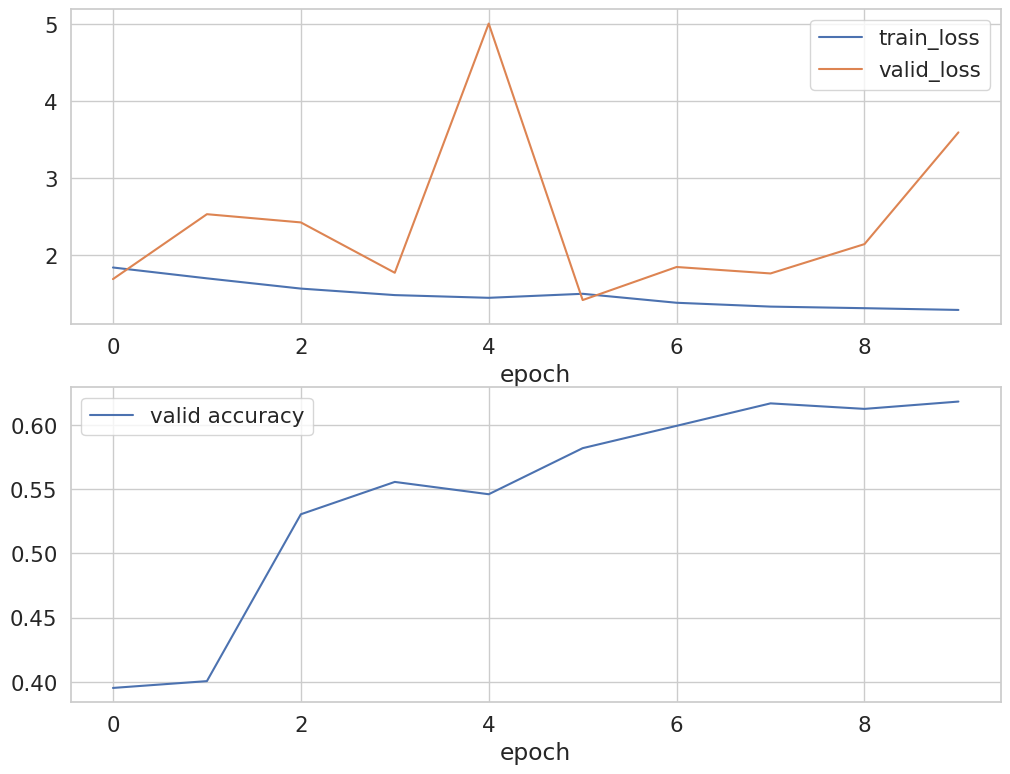

In [ ]:
model = ModelBatchNorm().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

info = fit(10, model, criterion, optimizer, *get_dataloaders(4))
plot_training(*info)

Вспомните как выглядели формулы для BatchNorm: если размер батча равен $1$, то $\sigma = 0$, и у нас есть деление на ноль. PyTorch **не умеет обрабатывать такой случай и падает**:

In [ ]:
model = ModelBatchNorm().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

fit(1, model, criterion, optimizer, *get_dataloaders(batch_size=1))

Files already downloaded and verified
Files already downloaded and verified

Epoch 1/1


Training:   0%|          | 0/50000 [00:00<?, ?it/s]

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 120])

# Dropout

<img src="https://wenkangwei.github.io/images/DL/dropout.jpg" width="1200" height="350">


Дропаут это еще один необычный слой, который используется в нейронных сетях. У него есть один гиперпараметр $p$.

Идея дропаута состоит в том, что во время обучения мы зануляем случайную часть входа и отдаем вход дальше (для каждого числа мы подбрасываем монетку и с вероятностью $p$ зануляем это число).

Дропаут позволяет тренировать более устойчивые сети и избегать переобучения.

### Dropout, механика работы.

Как мы сказали выше, dropout зануляет случайную часть входов и отдает их дальше. Допустим $p=0.5$ (достаточное популярное значение). Тогда мы просто убираем половину всего входа! Такое сильное воздействие явно плохо повлияет на качество нашей модели, поэтому мы делаем зануление только во время обучения.

**Во время обучения**: для каждого числа во входе подбрасываем монетку и зануляем его с вероятностью $p$. Выход умножаем на $\frac{1}{1-p}$, чтобы дисперсия выходов осталось такой же, как и на входе.

**Во время предсказаний**: ничего не делаем).

### Dropout, что дает?

* Сеть выучивает более устойчивые представления на внутренних слоях.
* Сильно увеличивает число итераций, которые нужны для сходимости.
* Можно получить интерпретацию, которая говорит, что дропаут усредняет выходы большо числа нейросетей с $p|W|$ нейронами на предыдущем слоев.

Дропаут вызывает интересный эффект: в начале обучения качество на тестовом датасете выше, чем на обучающем. Потому что для обучающего датасета у нас есть зануление, которое сильно портит предсказания.

### Dropout, взаимодействие с BatchNorm.

Статья, исследующая, почему исопльзование дропаута и батчнорма вместе часто ведет к более плохим результатам, чем их использование по-отдельности - https://arxiv.org/pdf/1801.05134.pdf

Картинка из статьи, объясняющая проблему:
![img](https://media.arxiv-vanity.com/render-output/3934414/x1.png)

(Если совсем коротко, то при наличии дропаута во время обучения и во время предсказаний выходы дропаута имеют разное распределение. Поэтому статистики, которые batchnorm считает для применения во время предсказаний, оказываются неверными.)

Решение: если вы хотите использовать батчнорм и дропаут в одной сети, то все Dropout"ы должны идти после BatchNorm"ов.

### Dropout, PyTorch

В PyTorch есть `F.dropout(x, p=p)` и слой `nn.Dropout(p=p)`. В чем их отличие? `F.dropout(x, p=p)` не будет изменять свое поведение в заивимости от того, в каком стостянии сейчас модель (train, eval).

Теперь чуть подробнее:

Когда вы вызываете model.train()/model.eval() PyTorch проходится по всем переменным класса и если видит там наследника nn.Module или nn.ModuleList, то также меняет состояние для всех найденных модулей. Т.е. версия со слоем будет автоматически работать с train/eval состяниями.

In [ ]:
class ModelDropout(nn.Module):
    def __init__(self):
        super(ModelDropout, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(3, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 5x5 image dimension
        self.dropout = nn.Dropout(p=0.3) #используют после послносвязных слоев
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.shape[0], -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


Epoch 1/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 1 -> Train Loss: 1.9330 | Val Loss: 1.8650 | Val Acc: 0.3059

Epoch 2/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 9 -> Train Loss: 1.9842 | Val Loss: 1.9314 | Val Acc: 0.2731

Epoch 10/10


Training:   0%|          | 0/12500 [00:00<?, ?it/s]

Validation:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 10 -> Train Loss: 1.9807 | Val Loss: 1.9331 | Val Acc: 0.2679


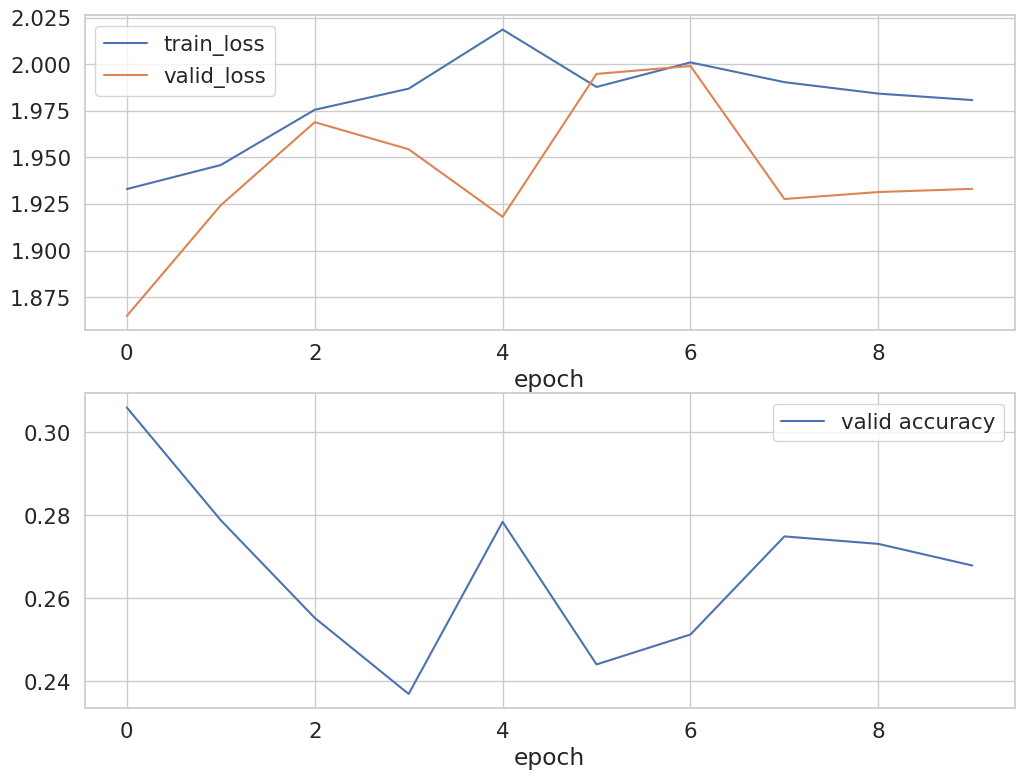

In [ ]:
model = ModelDropout().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.5)

info = fit(10, model, criterion, optimizer, *get_dataloaders(4))
plot_training(*info)